<a href="https://colab.research.google.com/github/Ashok-nimmala/EXAPLAINABLE-AI/blob/main/research.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import zipfile
from PIL import Image

zip_path = '/content/drive/MyDrive/pnemonia.zip'  # update path as needed

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    file_list = zip_ref.namelist()
    # Filter for image files (png, jpg, jpeg)
    img_files = [f for f in file_list if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    print(img_files[:5])  # Show first few image file names

    # Example: Read and display first image
    img_filename = img_files[0]  # select an actual image file
    with zip_ref.open(img_filename) as img_file:
        img = Image.open(img_file)
        img.show()



['COVID-19_Radiography_Dataset/COVID/images/COVID-1.png', 'COVID-19_Radiography_Dataset/COVID/images/COVID-10.png', 'COVID-19_Radiography_Dataset/COVID/images/COVID-100.png', 'COVID-19_Radiography_Dataset/COVID/images/COVID-1000.png', 'COVID-19_Radiography_Dataset/COVID/images/COVID-1001.png']


In [ ]:
import os
import zipfile
from collections import defaultdict

zip_path = '/content/drive/MyDrive/pnemonia.zip'  # adjust as needed

def load_patient_sequences_zip(zip_path, classes=['Viral Pneumonia', 'Normal']):
    patient_sequences = defaultdict(list)
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        files = zip_ref.namelist()
        for cls in classes:
            class_prefix = f'COVID-19_Radiography_Dataset/{cls}/'
            cls_files = [f for f in files
                         if f.startswith(class_prefix) and (f.endswith('.png') or f.endswith('.jpg'))]
            for f in cls_files:
                # Extract patient ID from filename
                fname = os.path.basename(f)
                patient_id = fname.split('_')[0]
                patient_sequences[patient_id].append(f)
        # Sort each patient's sequence by timestamp
        def extract_timestamp(fpath):
            try:
                return int(os.path.basename(fpath).split('_')[1].split('.')[0])
            except:
                return 0
        for pid in patient_sequences:
            patient_sequences[pid].sort(key=extract_timestamp)
        # Filter out patients with less than 2 scans
        patient_sequences = {pid: seq for pid, seq in patient_sequences.items() if len(seq) > 1}
    return patient_sequences

patient_sequences = load_patient_sequences_zip(zip_path)
print(f"Total valid patients with sequences: {len(patient_sequences)}")


Total valid patients with sequences: 11537


In [ ]:
import cv2
import numpy as np
from PIL import Image
import io

def segment_lung(img):
    _, thresh = cv2.threshold(img, 180, 255, cv2.THRESH_BINARY_INV)
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    mask = np.zeros_like(img)
    cv2.drawContours(mask, contours, -1, 255, -1)
    return mask

# Modified compute_features to accept bytes data from zip
def compute_features_from_bytes(img_bytes):
    img = Image.open(io.BytesIO(img_bytes)).convert('L')  # convert to grayscale
    img_np = np.array(img)
    img_resized = cv2.resize(img_np, (224, 224))
    lung_mask = segment_lung(img_resized)
    lung_pixels = img_resized[lung_mask == 255]
    opacity = (lung_pixels > 180).mean()  # fraction of high-opacity pixels
    left, right = lung_mask[:, :112], lung_mask[:, 112:]
    sym_index = abs(left.sum() - right.sum()) / (left.sum() + right.sum() + 1e-6)
    area = lung_mask.sum()  # lung area
    return opacity, sym_index, area


In [ ]:
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    img_path = 'COVID-19_Radiography_Dataset/COVID/images/COVID-1.png'
    with zip_ref.open(img_path) as img_file:
        img_bytes = img_file.read()
        opacity, sym_index, area = compute_features_from_bytes(img_bytes)
        print(opacity, sym_index, area)


0.00027078256160303275 1958845730789.8203 9417150


/tmp/ipython-input-288863589.py:22: RuntimeWarning: overflow encountered in scalar subtract
  sym_index = abs(left.sum() - right.sum()) / (left.sum() + right.sum() + 1e-6)


In [ ]:
!pip install torch-geometric torch-sparse


In [ ]:
import torch
from torch_geometric.data import Data
from torchvision.models import resnet18
import torch.nn.functional as F
import cv2
import numpy as np
from PIL import Image
import io
import zipfile

# Load pretrained CNN for node embeddings
cnn = resnet18(pretrained=True)
cnn.fc = torch.nn.Identity()
cnn.eval()

def preprocess_img_bytes(img_bytes):
    img = Image.open(io.BytesIO(img_bytes)).convert('RGB')
    img = img.resize((224, 224))
    img_np = np.array(img)
    img_t = torch.tensor(img_np).permute(2, 0, 1).unsqueeze(0).float() / 255.
    return img_t

def segment_lung(img):
    _, thresh = cv2.threshold(img, 180, 255, cv2.THRESH_BINARY_INV)
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    mask = np.zeros_like(img)
    cv2.drawContours(mask, contours, -1, 255, -1)
    return mask

def compute_features_bytes(img_bytes):
    img = Image.open(io.BytesIO(img_bytes)).convert('L')
    img_np = np.array(img)
    img_resized = cv2.resize(img_np, (224, 224))
    lung_mask = segment_lung(img_resized)
    lung_pixels = img_resized[lung_mask == 255]
    opacity = (lung_pixels > 180).mean()
    left, right = lung_mask[:, :112], lung_mask[:, 112:]
    sym_index = abs(left.sum() - right.sum()) / (left.sum() + right.sum() + 1e-6)
    area = lung_mask.sum()
    return opacity, sym_index, area

def build_patient_graph_from_zip(zip_path, scan_file_list):
    node_feats = []
    edge_index = [[], []]
    edge_attr = []

    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        with torch.no_grad():
            for f in scan_file_list:
                img_bytes = zip_ref.read(f)
                img_t = preprocess_img_bytes(img_bytes)
                emb = cnn(img_t).squeeze().numpy()
                node_feats.append(emb)
            for i in range(len(scan_file_list) - 1):
                f1_bytes = zip_ref.read(scan_file_list[i])
                f2_bytes = zip_ref.read(scan_file_list[i + 1])
                f1_feats = compute_features_bytes(f1_bytes)
                f2_feats = compute_features_bytes(f2_bytes)
                op_g = f2_feats[0] - f1_feats[0]
                sym_l = f2_feats[1] - f1_feats[1]
                vol_s = f1_feats[2] - f2_feats[2]
                edge_index[0].append(i)
                edge_index[1].append(i + 1)
                edge_attr.append([op_g, sym_l, vol_s])

    data = Data(
        x=torch.tensor(node_feats, dtype=torch.float),
        edge_index=torch.tensor(edge_index, dtype=torch.long),
        edge_attr=torch.tensor(edge_attr, dtype=torch.float)
    )
    return data


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [ ]:
import zipfile

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    print("Files in zip:")
    for f in zip_ref.namelist():
        print(f)


Files in zip:
COVID-19_Radiography_Dataset/COVID.metadata.xlsx
COVID-19_Radiography_Dataset/COVID/images/COVID-1.png
COVID-19_Radiography_Dataset/COVID/images/COVID-10.png
COVID-19_Radiography_Dataset/COVID/images/COVID-100.png
COVID-19_Radiography_Dataset/COVID/images/COVID-1000.png
COVID-19_Radiography_Dataset/COVID/images/COVID-1001.png
COVID-19_Radiography_Dataset/COVID/images/COVID-1002.png
COVID-19_Radiography_Dataset/COVID/images/COVID-1003.png
COVID-19_Radiography_Dataset/COVID/images/COVID-1004.png
COVID-19_Radiography_Dataset/COVID/images/COVID-1005.png
COVID-19_Radiography_Dataset/COVID/images/COVID-1006.png
COVID-19_Radiography_Dataset/COVID/images/COVID-1007.png
COVID-19_Radiography_Dataset/COVID/images/COVID-1008.png
COVID-19_Radiography_Dataset/COVID/images/COVID-1009.png
COVID-19_Radiography_Dataset/COVID/images/COVID-101.png
COVID-19_Radiography_Dataset/COVID/images/COVID-1010.png
COVID-19_Radiography_Dataset/COVID/images/COVID-1011.png
COVID-19_Radiography_Dataset/COV

In [ ]:
import zipfile
from collections import defaultdict

def group_patient_scans(zip_path, prefix_level=2):
    """
    Group scan file paths inside a ZIP by patient prefix.
    prefix_level determines how many folder levels define one group.
    For example, prefix_level=2 means 'COVID-19_Radiography_Dataset/Viral Pneumonia' is a group prefix.
    """
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        file_list = zip_ref.namelist()

    patient_groups = defaultdict(list)
    for f in file_list:
        # Split by '/' and join first prefix_level parts for group key
        parts = f.split('/')
        if len(parts) >= prefix_level:
            group_key = '/'.join(parts[:prefix_level])
            patient_groups[group_key].append(f)
        else:
            # Handle files with fewer parts, group separately
            patient_groups['ungrouped'].append(f)

    return patient_groups

# Usage example:
patient_scan_dict = group_patient_scans(zip_path, prefix_level=3)  # Adjust prefix_level as needed

# Print groups
for patient, scans in patient_scan_dict.items():
    print(f"Patient/group: {patient}")
    print(f"Scans: {scans[:5]} ...\n")  # Show first 5 scans only


Patient/group: ungrouped
Scans: ['COVID-19_Radiography_Dataset/COVID.metadata.xlsx', 'COVID-19_Radiography_Dataset/Lung_Opacity.metadata.xlsx', 'COVID-19_Radiography_Dataset/Normal.metadata.xlsx', 'COVID-19_Radiography_Dataset/README.md.txt', 'COVID-19_Radiography_Dataset/Viral Pneumonia.metadata.xlsx'] ...

Patient/group: COVID-19_Radiography_Dataset/COVID/images
Scans: ['COVID-19_Radiography_Dataset/COVID/images/COVID-1.png', 'COVID-19_Radiography_Dataset/COVID/images/COVID-10.png', 'COVID-19_Radiography_Dataset/COVID/images/COVID-100.png', 'COVID-19_Radiography_Dataset/COVID/images/COVID-1000.png', 'COVID-19_Radiography_Dataset/COVID/images/COVID-1001.png'] ...

Patient/group: COVID-19_Radiography_Dataset/COVID/masks
Scans: ['COVID-19_Radiography_Dataset/COVID/masks/COVID-1.png', 'COVID-19_Radiography_Dataset/COVID/masks/COVID-10.png', 'COVID-19_Radiography_Dataset/COVID/masks/COVID-100.png', 'COVID-19_Radiography_Dataset/COVID/masks/COVID-1000.png', 'COVID-19_Radiography_Dataset/CO

In [ ]:
pneumonia_images_group = None

for patient_group in patient_scan_dict.keys():
    if "Viral Pneumonia/images" in patient_group:
        pneumonia_images_group = patient_group
        break

if pneumonia_images_group:
    pneumonia_scans = patient_scan_dict[pneumonia_images_group]
    print(f"Pneumonia patient scans: {pneumonia_scans[:20]}")  # Show first 10 scans
else:
    print("No Pneumonia images group found.")


Pneumonia patient scans: ['COVID-19_Radiography_Dataset/Viral Pneumonia/images/Viral Pneumonia-1.png', 'COVID-19_Radiography_Dataset/Viral Pneumonia/images/Viral Pneumonia-10.png', 'COVID-19_Radiography_Dataset/Viral Pneumonia/images/Viral Pneumonia-100.png', 'COVID-19_Radiography_Dataset/Viral Pneumonia/images/Viral Pneumonia-1000.png', 'COVID-19_Radiography_Dataset/Viral Pneumonia/images/Viral Pneumonia-1001.png', 'COVID-19_Radiography_Dataset/Viral Pneumonia/images/Viral Pneumonia-1002.png', 'COVID-19_Radiography_Dataset/Viral Pneumonia/images/Viral Pneumonia-1003.png', 'COVID-19_Radiography_Dataset/Viral Pneumonia/images/Viral Pneumonia-1004.png', 'COVID-19_Radiography_Dataset/Viral Pneumonia/images/Viral Pneumonia-1005.png', 'COVID-19_Radiography_Dataset/Viral Pneumonia/images/Viral Pneumonia-1006.png', 'COVID-19_Radiography_Dataset/Viral Pneumonia/images/Viral Pneumonia-1007.png', 'COVID-19_Radiography_Dataset/Viral Pneumonia/images/Viral Pneumonia-1008.png', 'COVID-19_Radiograph

In [ ]:
losses = []

model.train()
for epoch in range(num_epochs):
    total_loss = 0
    for batch in loader:
        batch = batch.to(device)
        optimizer.zero_grad()

        pred = model(batch)
        loss = loss_fn(pred[:-1], batch.y[1:])

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
    avg_loss = total_loss / len(loader)
    losses.append(avg_loss)
    print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.4f}')


Epoch [1/20], Loss: 0.2995
Epoch [2/20], Loss: 0.2972
Epoch [3/20], Loss: 0.2949
Epoch [4/20], Loss: 0.2926
Epoch [5/20], Loss: 0.2904
Epoch [6/20], Loss: 0.2881
Epoch [7/20], Loss: 0.2858
Epoch [8/20], Loss: 0.2835
Epoch [9/20], Loss: 0.2813
Epoch [10/20], Loss: 0.2790
Epoch [11/20], Loss: 0.2768
Epoch [12/20], Loss: 0.2746
Epoch [13/20], Loss: 0.2723
Epoch [14/20], Loss: 0.2701
Epoch [15/20], Loss: 0.2679
Epoch [16/20], Loss: 0.2657
Epoch [17/20], Loss: 0.2635
Epoch [18/20], Loss: 0.2613
Epoch [19/20], Loss: 0.2592
Epoch [20/20], Loss: 0.2570


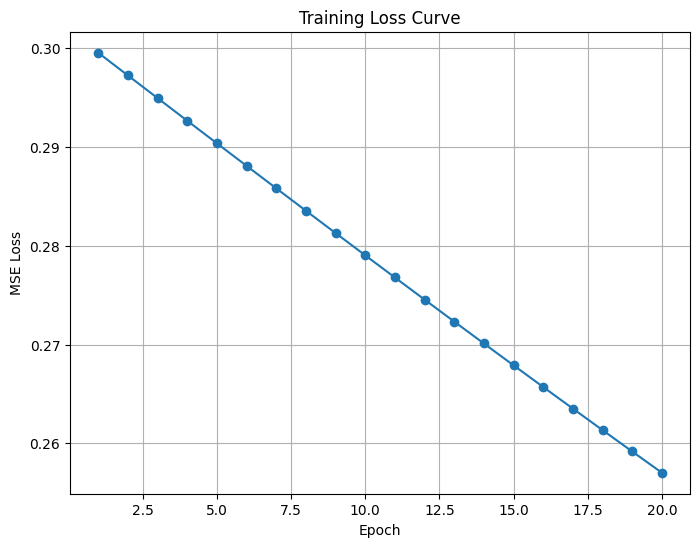

In [ ]:
import matplotlib.pyplot as plt

def plot_loss_curve(losses):
    plt.figure(figsize=(8,6))
    plt.plot(range(1, len(losses)+1), losses, marker='o')
    plt.title('Training Loss Curve')
    plt.xlabel('Epoch')
    plt.ylabel('MSE Loss')
    plt.grid(True)
    plt.show()

plot_loss_curve(losses)


In [ ]:
pnemonia_graphs = []

count = 0
max_patients = 20  # limit to first 20 patients

for group_key, scan_files in patient_scan_dict.items():
    if "Viral Pneumonia/images" in group_key and count < max_patients:
        print(f"Building graph for patient group: {group_key}")
        limited_scan_files = scan_files[:50]  # limit scans per patient if desired

        graph = build_patient_graph_from_zip(zip_path, limited_scan_files)
        graph.y = torch.rand(graph.num_nodes)  # add dummy label

        pnemonia_graphs.append(graph)
        count += 1

print(f"Total pneumonia patient graphs built and stored: {len(pnemonia_graphs)}")


Building graph for patient group: COVID-19_Radiography_Dataset/Viral Pneumonia/images


/tmp/ipython-input-2406611438.py:38: RuntimeWarning: overflow encountered in scalar subtract
  sym_index = abs(left.sum() - right.sum()) / (left.sum() + right.sum() + 1e-6)
/tmp/ipython-input-2406611438.py:61: RuntimeWarning: overflow encountered in scalar subtract
  vol_s = f1_feats[2] - f2_feats[2]


Total pneumonia patient graphs built and stored: 1


Visualizing patient 1/1


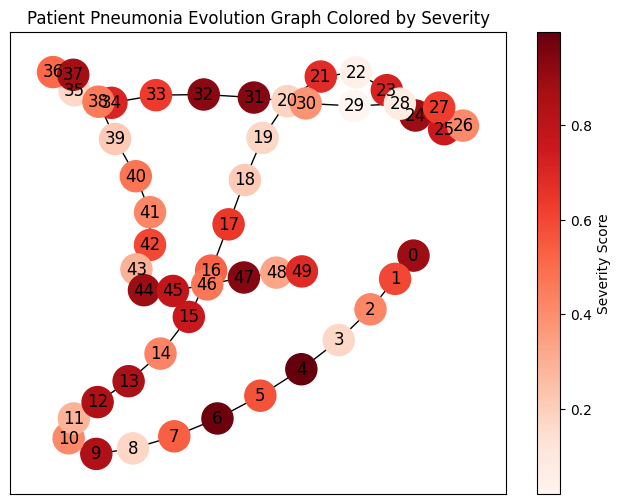

In [ ]:
for i, graph in enumerate(pnemonia_graphs):
    print(f"Visualizing patient {i+1}/{len(pnemonia_graphs)}")
    visualize_graph_with_severity(graph, graph.y)  # or graph.pred if available


In [ ]:
!pip install captum


Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/base_command.py", line 179, in exc_logging_wrapper
    status = run_func(*args)
             ^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/req_command.py", line 67, in wrapper
    return func(self, options, args)
           ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/commands/install.py", line 324, in run
    session = self.get_default_session(options)
              ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/index_command.py", line 71, in get_default_session
    self._session = self.enter_context(self._build_session(options))
                                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/index_command.py", line 100, in _build_session
    session = PipSession(
              ^^^^^^^^^

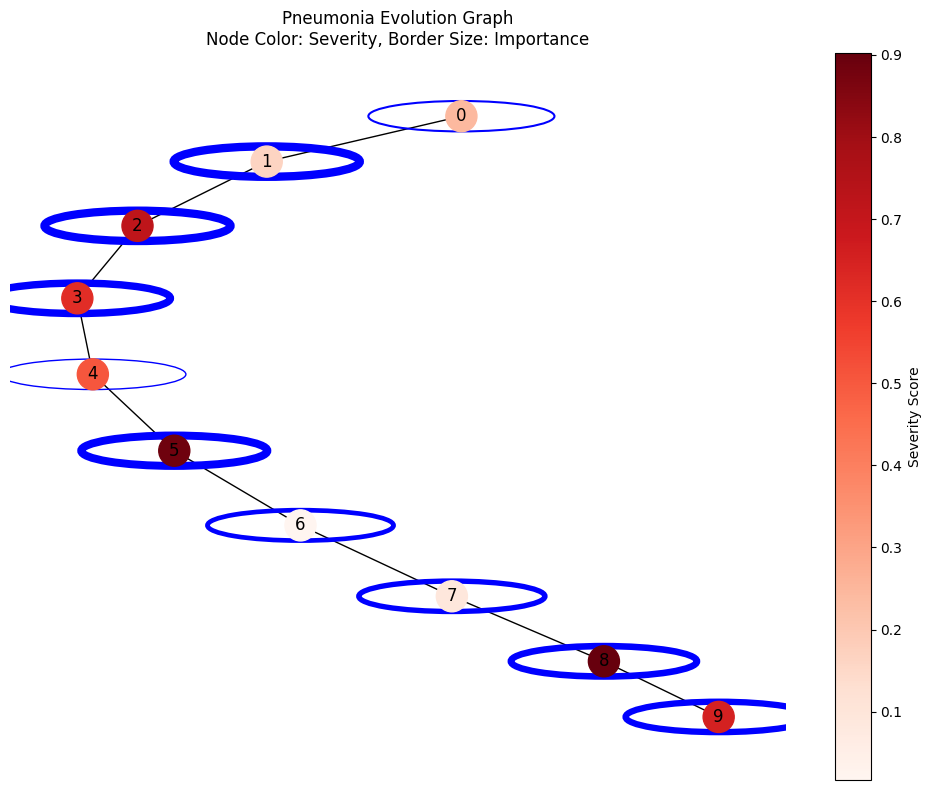

In [ ]:
import matplotlib.pyplot as plt
import networkx as nx
from torch_geometric.utils import to_networkx
import numpy as np
import torch

def visualize_graph_with_severity_and_importance(data, severity_scores, importance_scores, cmap='Reds'):
    G = to_networkx(data, to_undirected=True)
    severity = severity_scores.cpu().numpy() if hasattr(severity_scores, 'cpu') else np.array(severity_scores)
    importance = importance_scores.cpu().numpy() if hasattr(importance_scores, 'cpu') else np.array(importance_scores)

    plt.figure(figsize=(10, 8))
    pos = nx.spring_layout(G, seed=42)
    importance_norm = (importance - importance.min()) / (importance.max() - importance.min() + 1e-9)
    linewidths = 1 + 5 * importance_norm

    nodes = nx.draw_networkx_nodes(G, pos, node_size=500, node_color=severity, cmap=plt.get_cmap(cmap))
    nx.draw_networkx_edges(G, pos)
    nx.draw_networkx_labels(G, pos, font_color='black')

    ax = plt.gca()
    for i, (x, y) in pos.items():
        circle = plt.Circle((x, y), radius=0.05, fill=False, linewidth=linewidths[i], edgecolor='blue')
        ax.add_patch(circle)

    plt.title("Pneumonia Evolution Graph\nNode Color: Severity, Border Size: Importance")
    plt.colorbar(nodes, label='Severity Score')
    plt.axis('off')
    plt.tight_layout()
    plt.show()

# Dummy example data to test visualization independently
import torch_geometric
from torch_geometric.data import Data

# Make a simple line graph with 10 nodes
edge_index = torch.tensor([[i for i in range(9)] + [i+1 for i in range(9)],
                           [i+1 for i in range(9)] + [i for i in range(9)]], dtype=torch.long)

x = torch.randn((10, 3))   # dummy node features
y = torch.rand(10)         # dummy severity scores
importance = torch.rand(10)  # dummy importance scores

graph = Data(x=x, edge_index=edge_index)

# Call visualization
visualize_graph_with_severity_and_importance(graph, y, importance)


In [ ]:
import torch
import numpy as np
from sklearn.metrics import mean_squared_error

def evaluate_rmse(predictions, ground_truth):
    """
    Compute RMSE between predicted and true severity scores.

    Parameters:
    - predictions: torch tensor or numpy array of predicted severity values.
    - ground_truth: torch tensor or numpy array of true severity values.

    Returns:
    - RMSE float value.
    """
    # Convert torch tensors to numpy if needed
    if isinstance(predictions, torch.Tensor):
        predictions = predictions.detach().cpu().numpy()
    if isinstance(ground_truth, torch.Tensor):
        ground_truth = ground_truth.detach().cpu().numpy()

    rmse_val = np.sqrt(mean_squared_error(ground_truth, predictions))
    return rmse_val

# Example usage:
# pred = model(example_graph)          # predicted values tensor
# true = example_graph.y               # ground truth tensor
rmse = evaluate_rmse(pred, example_graph.y)
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")


Root Mean Squared Error (RMSE): 0.5074
